In [2]:
import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge, ElasticNet
from sklearn.model_selection import ParameterGrid

import sys
from itertools import product
sys.path.append('../../')
import src.forecasting.simulations      as sim
import src.fda.kde.estimators           as kde
import src.fda.transformations.lqdt     as lqdt
import src.fda.dfpc              as dfpc

In [3]:
# Define scenarios
gas_params = {
    # "scenario_1": {
    #     "Description": "Location-driven ($m_t$)",
    #     "alpha": np.diag([0.08, 0.01, 0.01]),
    #     "beta": np.diag([0.90, 0.95, 0.95]),
    # },
    # "scenario_2": {
    #     "Description": "Scale-driven ($\sigma_t$)",
    #     "alpha": np.diag([0.01, 0.08, 0.01]),
    #     "beta": np.diag([0.95, 0.90, 0.95]),
    # },
    # "scenario_3": {
    #     "Description": "Shape-driven ($\eta_t$)",
    #      "alpha": np.diag([0.01, 0.01, 0.08]),
    #       "beta": np.diag([0.95, 0.95, 0.90])
    # },
    "scenario_4": {
        "Description": "Mixture",
        "alpha": np.diag([0.04, 0.06, 0.04]),
        "beta": np.diag([0.92, 0.95, 0.94]),
    }
}

distribution_params = {
    "nu": [3]
}

keys = ["scenario", "nu"]
values = [list(gas_params.keys()), distribution_params["nu"]]

param_grid = []

for scenario, nu in product(*values):
    gas_cfg = gas_params[scenario]

    param_grid.append({
        "scenario": "___nu=".join([scenario, str(nu)]),
        "nu": nu,
        "alpha": gas_cfg["alpha"],
        "beta": gas_cfg["beta"]    
})

In [4]:
# grid for densities
x = np.linspace(-40, 40, 5001)
# number of curves (densities)
T = 301
# number of simulations (f_{N_REP,1},...,f_{N_REP,T})
N_REPS = 10
# number of samples from each f_t density
N_SAMPLES = 288

total = len(param_grid) * N_REPS

In [5]:
sim_database = {}
total = len(param_grid) * N_REPS

for params in param_grid:
    scenario = params["scenario"]
    # Initialize scenario level
    sim_database[scenario] = {
        "params": params,
        "replications": {}
    }
    
    for n_rep in range(N_REPS):
        # 1. Setup Model and Simulate
        gm = sim.GasModel(alpha=params["alpha"], beta=params["beta"], nu=params["nu"])
        sim_results = gm.simulate(T=T, burn_in=300)
        
        # 2. Get Theoretical Densities
        sim_density = gm.conditional_densities(grid=x, theta_path=sim_results["theta"])
        dates = pd.date_range(end=pd.Timestamp.today().normalize(), periods=T, freq="D")
        sim_density.columns = dates
        
        # 3. Generate Samples Efficiently
        # Collect arrays first, then create DataFrame once
        samples_list = []
        for i in range(len(sim_results["theta"])):
            # Draw n samples for the theta at time i
            sample = gm.rvs(n=N_SAMPLES, theta=sim_results["theta"][i])
            samples_list.append(sample)
        
        # Create DataFrame: each column is a time step, each row a sample
        df_samples = pd.DataFrame(np.array(samples_list).T, columns=dates)
        
        # 4. Store in Database
        sim_database[scenario]["replications"][n_rep] = {
            "theta": sim_results["theta"],
            "densities": sim_density,
            "samples": df_samples
        }

In [6]:
returns_df = sim_database['scenario_4___nu=3']['replications'][0]['samples']
# bandwidths
kde_bw_params = {"method": "rot", "kernel": "gaussian", "sigma_robust":False}

df_h = kde.df_bandwidth_selector(returns_df, **kde_bw_params)    
kde_params = {k: v for k, v in kde_bw_params.items() if k in ['kernel', 'df']}

# kdes
df_grids, df_densities = kde.df_to_kde(
    X=returns_df, 
    h=df_h, 
    normalize_densities=False,
    **kde_params
)

<Axes: >

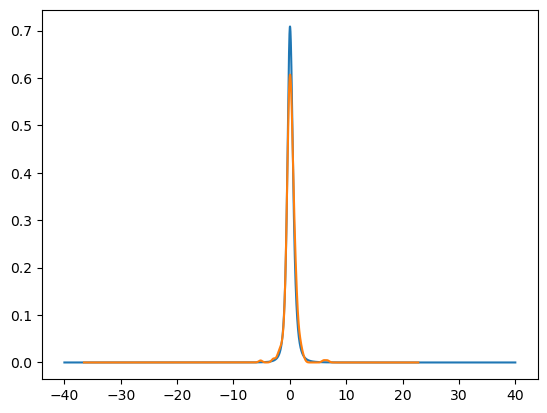

In [7]:
i = 100
sim_database['scenario_4___nu=3']['replications'][0]["densities"].iloc[:,i].plot(legend=False)
df_densities.iloc[:,i].plot(legend=False)

In [8]:
mlqdt = lqdt.mLQDT()
model_lqd = mlqdt.transform(
    densities=df_densities,
    densities_supports=df_grids, 
    verbose=False
    )
# model_lqd.densities_to_lqdensities(verbose=False)

# 2. L2 Expansion (K_dFPC)
Y_t  = model_lqd.lqd.copy()
Y_t.index = model_lqd.lqd_support

/opt/anaconda3/envs/densities4risk/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: overflow encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/opt/anaconda3/envs/densities4risk/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:504: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


<Axes: >

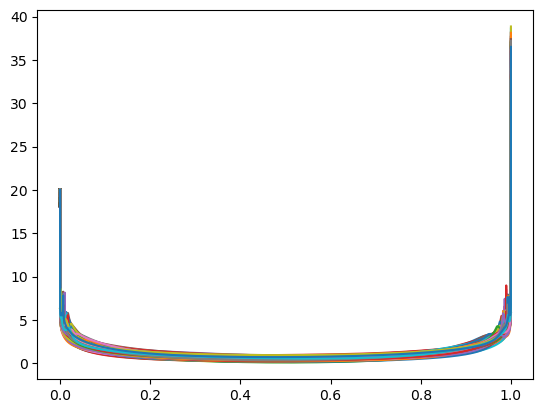

In [9]:
Y_t.plot(legend=False)

In [10]:
KdFPC_kwargs = {
    "p": 5,
    "dimension": 3
}

In [11]:
Y_train, Y_test = Y_t.iloc[:,:-1], Y_t.iloc[:,-1]

In [12]:
lqd_values  = Y_train.values
lqd_support = Y_train.index.values

KdFPC_kwargs.update({
    "u": lqd_support,
    "du": model_lqd.du
})

model_kdfpc = dfpc.K_dFPC(lqd_values)
model_kdfpc.fit(**KdFPC_kwargs)

In [18]:
etas = model_kdfpc.etahat
etas

,scores_1,scores_2,scores_3
0,0.262641,-0.190520,0.012266
1,0.313956,-0.047981,-0.033664
2,0.176174,-0.002703,-0.064430
3,0.224807,-0.148362,-0.062845
4,0.157285,0.010321,0.034310
...,...,...,...
295,-0.023299,-0.033663,-0.031322
296,0.075158,0.017635,-0.065304
297,-0.125337,-0.048938,0.056870
298,0.328029,-0.061655,-0.020491


In [ ]:
# class ScoreForecaster:
#     """
#     Forecast functional principal component (FPC) scores using
#     regularized supervised learning models.

#     The class fits one regression model per score component.

#     Let

#         eta_t = (eta_{t1}, ..., eta_{td})

#     denote the d-dimensional vector of FPC scores at time t.

#     Given a lag order L, the predictor vector is

#         X_t = (eta_{t-L}, ..., eta_{t-1})

#     and the response is

#         eta_t.

#     For each component j = 1, ..., d, a separate regression model

#         eta_{tj} = H_j(X_t)

#     is estimated.

#     Supported models
#     ----------------
#     ridge
#         Ridge regression.

#     elasticnet
#         Elastic Net regression.

#     Parameters
#     ----------
#     model : str, default='ridge'
#         Regression algorithm.

#     lag : int, default=1
#         Number of lagged score vectors used as predictors.

#     model_params : dict, optional
#         Additional parameters passed to the selected model.

#     Attributes
#     ----------
#     models_ : list
#         List of fitted models, one for each score.

#     n_components_ : int
#         Number of FPC scores.

#     Examples
#     --------
#     >>> eta.shape
#     (500, 3)

#     >>> forecaster = ScoreForecaster(
#     ...     model="ridge",
#     ...     lag=5
#     ... )

#     >>> forecaster.fit(eta)

#     >>> eta_next = forecaster.predict_next(eta)

#     >>> eta_next.shape
#     (3,)
#     """

#     def __init__(
#         self,
#         model="ridge",
#         lag=1,
#         model_params=None
#     ):

#         self.model_name = model.lower()
#         self.lag = lag
#         self.model_params = model_params or {}

#         self.models_ = None
#         self.n_components_ = None

#     def _build_model(self):
#         """
#         Construct the selected regression model.

#         Returns
#         -------
#         estimator
#             Unfitted regression estimator.
#         """

#         if self.model_name == "ridge":

#             return Ridge(
#                 alpha=self.model_params.get("alpha", 1.0)
#             )

#         elif self.model_name == "elasticnet":

#             return ElasticNet(
#                 alpha=self.model_params.get("alpha", 1.0),
#                 l1_ratio=self.model_params.get("l1_ratio", 0.5),
#                 max_iter=self.model_params.get("max_iter", 10000)
#             )

#         else:

#             raise ValueError(
#                 f"Unknown model '{self.model_name}'. "
#                 "Available models are "
#                 "'ridge', 'elasticnet', and 'lightgbm'."
#             )

#     def _build_design_matrix(self, eta):
#         """
#         Construct lagged predictor and response matrices.

#         Parameters
#         ----------
#         eta : ndarray of shape (T, d)
#             Matrix of FPC scores.

#         Returns
#         -------
#         X : ndarray of shape (T-lag, lag*d)
#             Predictor matrix.

#         Y : ndarray of shape (T-lag, d)
#             Response matrix.

#         Examples
#         --------
#         For lag = 2,

#         X[0] contains

#             (eta_1, eta_2)

#         and

#         Y[0] contains

#             eta_3.
#         """

#         T, d = eta.shape

#         X = []
#         Y = []

#         for t in range(self.lag, T):

#             X.append(
#                 eta[t-self.lag:t].reshape(-1)
#             )

#             Y.append(
#                 eta[t]
#             )

#         return np.asarray(X), np.asarray(Y)

#     def fit(self, eta):
#         """
#         Fit one model per FPC score.

#         Parameters
#         ----------
#         eta : ndarray of shape (T, d)
#             Matrix of observed FPC scores.

#         Returns
#         -------
#         self : ScoreForecaster

#         Examples
#         --------
#         >>> forecaster.fit(eta)
#         """

#         X, Y = self._build_design_matrix(eta)

#         self.n_components_ = Y.shape[1]

#         self.models_ = []

#         for j in range(self.n_components_):

#             model = self._build_model()

#             model.fit(
#                 X,
#                 Y[:, j]
#             )

#             self.models_.append(model)

#         return self

#     def predict_next(self, eta):
#         """
#         Compute a one-step-ahead forecast of the score vector.

#         Parameters
#         ----------
#         eta : ndarray of shape (T, d)
#             Historical score matrix.

#         Returns
#         -------
#         eta_hat : ndarray of shape (d,)
#             Forecasted score vector.

#         Examples
#         --------
#         >>> eta_next = forecaster.predict_next(eta)

#         >>> eta_next
#         array([0.124, -0.031, 0.551])
#         """

#         x = eta[-self.lag:].reshape(1, -1)

#         preds = np.zeros(self.n_components_)

#         for j, model in enumerate(self.models_):

#             preds[j] = model.predict(x)[0]

#         return preds.reshape([-1,1])

#     def fitted_values(self, eta):
#         """
#         Obtain in-sample fitted score forecasts.

#         Parameters
#         ----------
#         eta : ndarray of shape (T, d)
#             Historical score matrix.

#         Returns
#         -------
#         ndarray of shape (T-lag, d)
#             Matrix of fitted values.

#         Notes
#         -----
#         Row t contains the fitted prediction for eta_t
#         based on the previous `lag` score vectors.

#         Examples
#         --------
#         >>> eta_fit = forecaster.fitted_values(eta)

#         >>> eta_fit.shape
#         (T - lag, d)
#         """

#         X, _ = self._build_design_matrix(eta)

#         preds = np.zeros(
#             (X.shape[0], self.n_components_)
#         )

#         for j, model in enumerate(self.models_):

#             preds[:, j] = model.predict(X)

#         return preds

In [ ]:
import numpy as np

from sklearn.linear_model import Ridge, ElasticNet

class ScoreForecaster:
    """
    Forecast FPC scores from intraday observations.

    The model estimates

        eta_{t,j} = H_j(z_{t-1}, ..., z_{t-lag})

    separately for each score j.

    Parameters
    ----------
    model : {"ridge", "elasticnet", "lightgbm"}
        Regression algorithm.

    lag : int, default=1
        Number of previous days used as predictors.

    model_params : dict, optional
        Parameters passed to the regression model.

    Notes
    -----
    If each day contains m intraday observations and lag=L,
    then each predictor vector has dimension

        m * L

    Example
    -------
    Suppose

        samples.shape = (300, 288)
        scores.shape  = (300, 3)

    Then

        forecaster.fit(samples, scores)

    learns

        eta_t = H(z_{t-1})

    and

        forecaster.predict_next(samples)

    returns a 3-dimensional score forecast.
    """

    def __init__(
        self,
        model="ridge",
        lag=1,
        model_params=None
    ):

        self.model_name = model.lower()
        self.lag = lag
        self.model_params = model_params or {}

        self.models_ = None
        self.n_components_ = None

    def _build_model(self):

        if self.model_name == "ridge":

            return Ridge(
                alpha=self.model_params.get(
                    "alpha", 1.0
                )
            )

        elif self.model_name == "elasticnet":

            return ElasticNet(
                alpha=self.model_params.get(
                    "alpha", 1.0
                ),
                l1_ratio=self.model_params.get(
                    "l1_ratio", 0.5
                ),
                max_iter=self.model_params.get(
                    "max_iter", 10000
                )
            )

        raise ValueError(
            f"Unknown model '{self.model_name}'."
        )

    def _build_design_matrix(
        self,
        samples,
        scores
    ):
        """
        Construct lagged intraday predictors.

        Parameters
        ----------
        samples : ndarray (T, m)
            Intraday observations.

        scores : ndarray (T, d)
            FPC scores.

        Returns
        -------
        X : ndarray
            Predictor matrix.

        Y : ndarray
            Response matrix.
        """

        T, m = samples.shape
        _, d = scores.shape

        X = []
        Y = []

        for t in range(self.lag, T):

            predictors = samples[
                t-self.lag:t
            ].reshape(-1)

            X.append(predictors)

            Y.append(scores[t])

        return (
            np.asarray(X),
            np.asarray(Y)
        )

    def fit(
        self,
        samples,
        scores
    ):
        """
        Fit forecasting models.

        Parameters
        ----------
        samples : ndarray (T, m)
            Intraday observations.

        scores : ndarray (T, d)
            FPC score matrix.

        Returns
        -------
        self
        """

        X, Y = self._build_design_matrix(
            samples,
            scores
        )

        self.n_components_ = Y.shape[1]

        self.models_ = []

        for j in range(self.n_components_):

            model = self._build_model()

            model.fit(
                X,
                Y[:, j]
            )

            self.models_.append(model)

        return self

    def predict_next(
        self,
        samples
    ):
        """
        Forecast next score vector.

        Parameters
        ----------
        samples : ndarray (T, m)

        Returns
        -------
        ndarray (d,)
        """

        x = samples[
            -self.lag:
        ].reshape(1, -1)

        preds = np.zeros(
            self.n_components_
        )

        for j, model in enumerate(
            self.models_
        ):
            preds[j] = model.predict(x)[0]

        return preds.reshape([-1,1])

    def fitted_values(
        self,
        samples,
        scores
    ):
        """
        In-sample fitted score forecasts.

        Returns
        -------
        ndarray (T-lag, d)
        """

        X, _ = self._build_design_matrix(
            samples,
            scores
        )

        preds = np.zeros(
            (
                X.shape[0],
                self.n_components_
            )
        )

        for j, model in enumerate(
            self.models_
        ):
            preds[:, j] = model.predict(X)

        return preds

In [53]:
forecaster = ScoreForecaster(
    model="ridge",
    lag=3
)

samples = df_samples.iloc[:, :-1].values

forecaster.fit(samples, etas.values)

eta_fc_1 = forecaster.predict_next(samples)

forecaster = ScoreForecaster(
    model="elasticnet",
    lag=3
)

samples = df_samples.iloc[:, :-1].values

forecaster.fit(samples, etas.values)

eta_fc_2 = forecaster.predict_next(samples)

In [54]:
model_kdfpc.Ybar

array([[19.95447282],
       [ 6.5593398 ],
       [ 6.02281691],
       ...,
       [ 6.02490594],
       [ 6.56132606],
       [33.38858458]], shape=(5001, 1))

In [55]:
eta_fc

array([[0.06807604],
       [0.08282391],
       [0.00819191]])

In [56]:
model_kdfpc.psihat

,basis_1,basis_2,basis_3
0,-0.008698,0.006540,-0.005736
1,0.906475,-0.262331,0.860026
2,0.925136,-0.253952,0.888909
3,0.942182,-0.247471,0.914782
4,0.958190,-0.240251,0.942331
...,...,...,...
4996,0.841939,-0.325074,1.767151
4997,0.859125,-0.357133,1.539207
4998,0.876616,-0.401124,1.297704
4999,0.900279,-0.480467,0.994643


In [57]:
Y_n_p_1 = model_kdfpc.predict(eta_fc_1)
Y_n_p_1.index = Y_test.index
Y_n_p_1

,0
0.0000,19.954375
0.0002,6.606367
0.0004,6.072045
0.0006,5.784456
0.0008,5.597539
...,...
0.9992,5.591626
0.9994,5.776987
0.9996,6.061990
0.9998,6.590967


In [58]:
Y_n_p_2 = model_kdfpc.predict(eta_fc_2)
Y_n_p_2.index = Y_test.index
Y_n_p_2

,0
0.0000,19.954504
0.0002,6.557293
0.0004,6.020766
0.0006,5.731260
0.0008,5.542426
...,...
0.9992,5.544393
0.9994,5.733045
0.9996,6.022386
0.9998,6.558617


(0.0, 10.0)

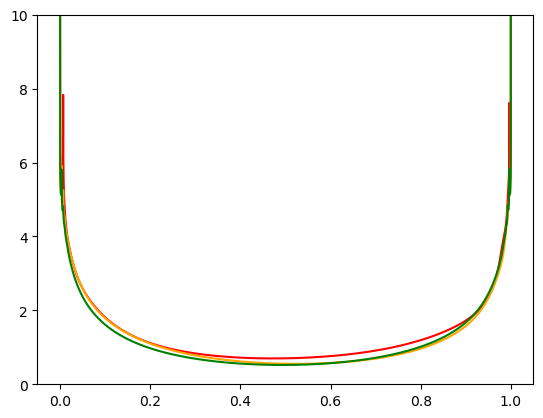

In [59]:
import matplotlib.pyplot as plt

Y_test.plot(color="red")
Y_n_p_1.iloc[:,0].plot(color="orange")
Y_n_p_2.iloc[:,0].plot(color="green")
plt.ylim([-0,10])

In [81]:
import numpy as np
import pandas as pd

class SimulationForecaster:
    """
    Time-series forecaster for Probability Density Functions (PDFs).

    This class implements a forecasting pipeline for functional data (densities) 
    by mapping them into a Hilbert space using the Log-Quantile Density (LQD) 
    transformation. It reduces dimensionality via Karhunen-Loève dynamic Functional 
    Principal Component (K-dFPC) Analysis and forecasts the resulting 
    coefficients using a multivariate ScoreForecaster.

    Parameters
    ----------
    kdfpc_kwargs : dict, optional
        Keyword arguments passed to the `dfpc.K_dFPC` model (e.g., n_components).
    forecaster_model : str, default='ridge'
        The underlying model type used by the ScoreForecaster.
    lag : int, default=3
        The number of lags to consider for the score forecaster.

    Attributes
    ----------
    model_lqd : lqdt.mLQDT
        The fitted LQD transformation object containing LQD curves and constants.
    model_kdfpc : dfpc.K_dFPC
        The fitted Functional PCA model.
    score_forecaster : ScoreForecaster
        The fitted multivariate forecaster for PCA scores.
    """
    
    def __init__(self, kdfpc_kwargs=None, forecaster_model="ridge", lag=3):
        self.kdfpc_kwargs = kdfpc_kwargs or {}
        self.forecaster_model = forecaster_model
        self.lag = lag
        
        # Initialized during fitting
        self.returns = None
        self.model_lqd = None
        self.model_kdfpc = None
        self.score_forecaster = None

    def fit(self, Y_train: pd.DataFrame, Y_support: pd.DataFrame, returns: pd.DataFrame):
        """
        Fits the LQD transformation, Functional PCA, and the internal ScoreForecaster.
        """
        self.returns = returns
        # 1. Transform Densities to LQD Space
        mlqdt = lqdt.mLQDT()
        self.model_lqd = mlqdt.transform(
            densities=Y_train,
            densities_supports=Y_support, 
            verbose=False
        )
        
        # 2. Extract L2 Expansion (K_dFPC)
        lqd_values = self.model_lqd.lqd.values
        lqd_support = self.model_lqd.lqd_support
        
        # Use a copy to avoid mutating constructor configurations dynamically
        kdfpc_params = self.kdfpc_kwargs.copy()
        kdfpc_params.update({
            "u": lqd_support,
            "du": self.model_lqd.du
        })
        
        self.model_kdfpc = dfpc.K_dFPC(lqd_values)
        self.model_kdfpc.fit(**kdfpc_params)
        
        # 3. Fit Multivariate Score Forecaster
        scores = self.model_kdfpc.etahat.values.real
        
        self.score_forecaster = ScoreForecaster(
            model=self.forecaster_model,
            lag=self.lag
        )
        self.score_forecaster.fit(returns.values, scores)

        return self

    def predict(self, horizon: int, forecast_index: pd.Index = None) -> dict:
        """
        Forecasts future scores, reconstructs LQD curves, and inverts them back to densities.
        """
        if self.score_forecaster is None:
            raise RuntimeError("The forecaster must be fitted before calling predict.")

        # Build forecasted index labels
        if forecast_index is not None:
            if len(forecast_index) != horizon:
                raise ValueError(f"forecast_index length ({len(forecast_index)}) must match horizon ({horizon})")
            future_dates = forecast_index
        else:
            future_dates = np.arange(horizon)
        
        # 1. Forecast Scores
        k_etahat_fc = self.score_forecaster.predict_next(self.returns.values)
        
        # 2. Reconstruct LQD Curves
        L2_curve_forecast = self.model_kdfpc.predict(k_etahat_fc)
        L2_curve_forecast.columns = future_dates
        
        
        return {
            "future_L2_curves": L2_curve_forecast,
            "future_scores": k_etahat_fc
        }

In [82]:
Y_train, Y_test = df_densities.iloc[:,:-1], df_densities.iloc[:,-1]
Y_supp_train, Y_supp_test = df_grids.iloc[:,:-1], df_grids.iloc[:,-1]
returns_train = df_samples.iloc[:,:-1]

In [93]:

forecaster = SimulationForecaster(kdfpc_kwargs=KdFPC_kwargs)
forecaster.fit(Y_train, Y_supp_train, returns=returns_train)
results = forecaster.predict(horizon=1, forecast_index=Y_test.to_frame().columns)

/opt/anaconda3/envs/densities4risk/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: overflow encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/opt/anaconda3/envs/densities4risk/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:504: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


In [96]:

forecaster = SimulationForecaster(kdfpc_kwargs=KdFPC_kwargs, forecaster_model="elasticnet")
forecaster.fit(Y_train, Y_supp_train, returns=returns_train)
results = forecaster.predict(horizon=1,forecast_index=Y_test.to_frame().columns)
results["future_L2_curves"]

/opt/anaconda3/envs/densities4risk/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: overflow encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/opt/anaconda3/envs/densities4risk/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:504: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


,2026-06-01
0,19.954504
1,6.557293
2,6.020766
3,5.731260
4,5.542426
...,...
4996,5.544393
4997,5.733045
4998,6.022386
4999,6.558617
